## Bitcoin training for XGBoost model

In [2]:
import pandas as pd
import numpy as np
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

random.seed(42)
np.random.seed(42)

In [3]:
btc_df_xgb = pd.read_csv(r'feature_datasets\BTC_features.csv', parse_dates=True, index_col=0)

print(btc_df_xgb.shape)
btc_df_xgb.head()

(916, 30)


,Close,High,Low,Open,Volume,Daily_Return,Close_Lag_1,Close_Lag_7,Close_Lag_14,Close_Lag_30,...,HL_Spread,Volume_MA_7,Volume_MA_21,Volume_MA_60,Volume_MA_180,Volume_Change,Target_Return_7,Target_Return_30,Target_Return_365,Target_Up
Date,,,,,,,,,,,,,,,,,,,,,
2021-06-30,35040.835938,36074.757812,34086.152344,35908.386719,3.405904e+10,-0.023055,35867.777344,33723.027344,38347.062500,37332.855469,...,1988.605469,3.618633e+10,4.010540e+10,5.205674e+10,6.151002e+10,-0.101379,-0.033832,0.205324,-0.435381,0
2021-07-01,33572.117188,35035.984375,32883.781250,35035.984375,3.783896e+10,-0.041914,35040.835938,34662.437500,38053.503906,36684.925781,...,2152.203125,3.685999e+10,3.983221e+10,5.205110e+10,6.134320e+10,0.110981,-0.020694,0.239904,-0.426031,0
2021-07-02,33897.046875,33939.589844,32770.679688,33549.601562,3.872897e+10,0.009679,33572.117188,31637.779297,35787.246094,37575.179688,...,1168.910156,3.664543e+10,3.983360e+10,5.183470e+10,6.112133e+10,0.023521,-0.002922,0.179303,-0.432332,0
2021-07-03,34668.546875,34909.261719,33402.695312,33854.421875,2.438396e+10,0.022760,33897.046875,32186.277344,35615.871094,39208.765625,...,1506.566406,3.461665e+10,3.918883e+10,5.109835e+10,6.080589e+10,-0.370395,-0.033114,0.130764,-0.443384,0
2021-07-04,35287.781250,35937.566406,34396.476562,34665.566406,2.492431e+10,0.017862,34668.546875,34649.644531,35698.296875,36894.406250,...,1541.089844,3.310417e+10,3.843908e+10,5.035973e+10,6.056910e+10,0.022160,-0.029687,0.081195,-0.426678,0


In [4]:
# Target = next-day Close
btc_y_xgb = btc_df_xgb['Close'].shift(-1)

# Features = all columns except Close
btc_X_xgb = btc_df_xgb.drop(columns=['Close'])

# Drop last row because shifted target becomes NaN
btc_X_xgb = btc_X_xgb.iloc[:-1]
btc_y_xgb = btc_y_xgb.iloc[:-1]

print("BTC X shape:", btc_X_xgb.shape)
print("BTC y shape:", btc_y_xgb.shape)

BTC X shape: (915, 29)
BTC y shape: (915,)


In [5]:
split_idx = int(len(btc_X_xgb) * 0.7)

btc_X_train_xgb = btc_X_xgb.iloc[:split_idx]
btc_X_test_xgb = btc_X_xgb.iloc[split_idx:]

btc_y_train_xgb = btc_y_xgb.iloc[:split_idx]
btc_y_test_xgb = btc_y_xgb.iloc[split_idx:]

print("X_train shape:", btc_X_train_xgb.shape)
print("X_test shape:", btc_X_test_xgb.shape)
print("y_train shape:", btc_y_train_xgb.shape)
print("y_test shape:", btc_y_test_xgb.shape)

X_train shape: (640, 29)
X_test shape: (275, 29)
y_train shape: (640,)
y_test shape: (275,)


In [6]:
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

model_xgb.fit(btc_X_train_xgb, btc_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
btc_preds_xgb = model_xgb.predict(btc_X_test_xgb)

print("Predictions shape:", btc_preds_xgb.shape)
print("First 10 predictions:", btc_preds_xgb[:10])

Predictions shape: (275,)
First 10 predictions: [28719.111 28305.068 27793.207 27989.092 28319.656 28001.367 27868.691
 27831.312 28043.07  28158.416]


In [8]:
mse_xgb = mean_squared_error(btc_y_test_xgb, btc_preds_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(btc_y_test_xgb, btc_preds_xgb)
r2_xgb = r2_score(btc_y_test_xgb, btc_preds_xgb)
mape_xgb = np.mean(np.abs((btc_y_test_xgb - btc_preds_xgb) / btc_y_test_xgb)) * 100

print("XGBoost Results:")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"MAPE: {mape_xgb:.2f}%")

XGBoost Results:
MSE: 1577722.08
RMSE: 1256.07
MAE: 946.26
R2 Score: 0.9438
MAPE: 2.99%


In [13]:
results_xgb = pd.DataFrame({
    "Actual": btc_y_test_xgb.values,
    "Predicted": btc_preds_xgb
})

results_xgb.head()

,Actual,Predicted
0,28199.308594,28719.111328
1,27790.220703,28305.068359
2,28168.089844,27793.207031
3,28177.984375,27989.091797
4,28044.140625,28319.656250


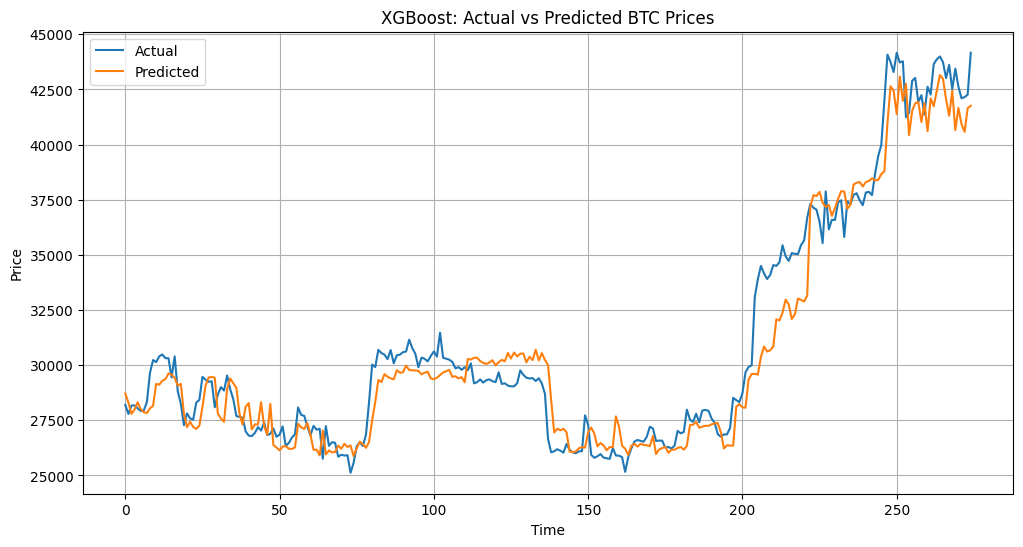

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(btc_y_test_xgb,btc_y_test_xgb.values, label="Actual")
plt.plot(btc_y_test_xgb,btc_preds_xgb, label="Predicted")
plt.title("XGBoost: Actual vs Predicted BTC Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

              Feature  Importance
0                High    0.525844
1                 Low    0.304431
2                Open    0.089521
11               MA_7    0.024643
5         Close_Lag_1    0.013829
27  Target_Return_365    0.007204
14             MA_180    0.005186
23      Volume_MA_180    0.004717
22       Volume_MA_60    0.003876
17      Volatility_60    0.002423


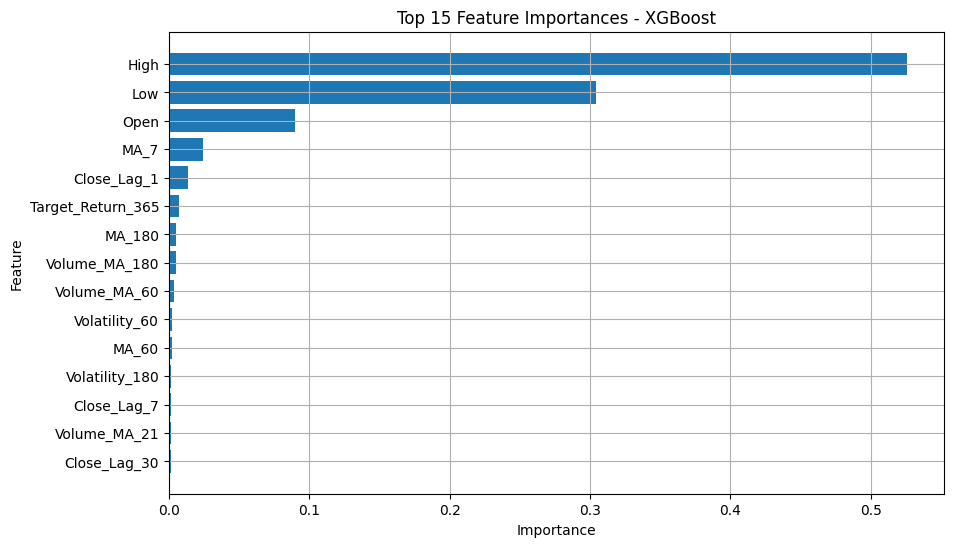

In [11]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": btc_X_train_xgb.columns,
    "Importance": model_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"].head(15)[::-1], importance["Importance"].head(15)[::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

## Finetuning the XGBoost model

In [14]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    model_xgb_opt = XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        objective="reg:squarederror",
        random_state=42
    )

    model_xgb_opt.fit(btc_X_train_xgb, btc_y_train_xgb)

    preds_xgb_opt = model_xgb_opt.predict(btc_X_test_xgb)

    rmse_xgb_opt = np.sqrt(mean_squared_error(btc_y_test_xgb, preds_xgb_opt))
    return rmse_xgb_opt

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
study_xgb = optuna.create_study(
    direction="minimize",
    study_name="xgb_optuna_btc",
    storage="sqlite:///xgb_optuna_btc.db",
    load_if_exists=True
)

study_xgb.optimize(objective, n_trials=50)

[I 2026-04-04 00:02:40,079] A new study created in memory with name: no-name-1a48caab-d8cf-40ab-9870-a0a01bf2e3fd
[I 2026-04-04 00:02:41,109] Trial 0 finished with value: 3685.100357663686 and parameters: {'n_estimators': 180, 'max_depth': 7, 'learning_rate': 0.0027210485930102427, 'subsample': 0.8598023319685797, 'colsample_bytree': 0.6377677691403275}. Best is trial 0 with value: 3685.100357663686.
[I 2026-04-04 00:02:42,059] Trial 1 finished with value: 3615.6779748252643 and parameters: {'n_estimators': 460, 'max_depth': 3, 'learning_rate': 0.0010781998456539388, 'subsample': 0.6331092518991593, 'colsample_bytree': 0.6944180251272251}. Best is trial 1 with value: 3615.6779748252643.
[I 2026-04-04 00:02:43,448] Trial 2 finished with value: 1606.0482759876227 and parameters: {'n_estimators': 456, 'max_depth': 4, 'learning_rate': 0.09016823915937326, 'subsample': 0.8882864539264852, 'colsample_bytree': 0.7842387716221755}. Best is trial 2 with value: 1606.0482759876227.
[I 2026-04-04 

In [27]:
print("Best XGBoost RMSE:", study_xgb.best_value)
print("Best XGBoost Parameters:", study_xgb.best_params)

Best XGBoost RMSE: 1197.5375996561706
Best XGBoost Parameters: {'n_estimators': 318, 'max_depth': 9, 'learning_rate': 0.20491504547795927, 'subsample': 0.8086045988772522, 'colsample_bytree': 0.7657505990112772}


In [28]:
best_params_xgb = study_xgb.best_params

model_xgb_best = XGBRegressor(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    colsample_bytree=best_params_xgb["colsample_bytree"],
    objective="reg:squarederror",
    random_state=42
)

model_xgb_best.fit(btc_X_train_xgb, btc_y_train_xgb)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7657505990112772
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import

In [29]:
btc_preds_xgb_best = model_xgb_best.predict(btc_X_test_xgb)

print("Predictions shape:", btc_preds_xgb_best.shape)
print("First 10 predictions:", btc_preds_xgb_best[:10])

Predictions shape: (275,)
First 10 predictions: [28568.926 28383.072 27326.615 27922.293 28077.469 28085.727 27023.396
 27057.152 28548.477 28918.2  ]


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_xgb_best = mean_squared_error(btc_y_test_xgb, btc_preds_xgb_best)
rmse_xgb_best = np.sqrt(mse_xgb_best)
mae_xgb_best = mean_absolute_error(btc_y_test_xgb, btc_preds_xgb_best)
r2_xgb_best = r2_score(btc_y_test_xgb, btc_preds_xgb_best)
mape_xgb_best = np.mean(np.abs((btc_y_test_xgb - btc_preds_xgb_best) / btc_y_test_xgb)) * 100

print("Best XGBoost Results:")
print(f"MSE: {mse_xgb_best:.2f}")
print(f"RMSE: {rmse_xgb_best:.2f}")
print(f"MAE: {mae_xgb_best:.2f}")
print(f"R2 Score: {r2_xgb_best:.4f}")
print(f"MAPE: {mape_xgb_best:.2f}%")

Best XGBoost Results:
MSE: 1434096.30
RMSE: 1197.54
MAE: 908.44
R2 Score: 0.9489
MAPE: 2.85%
